# Hoja de Trabajo #2: Transformers y Mecanismos de Atención
**Curso:** CC3092 - Deep Learning y Sistemas Inteligentes  
**Estudiante:** Javier España (Carné: 23361)  
**Repositorio Git:** [https://github.com/Javier-Espana/HT2-DL.git](https://github.com/Javier-Espana/HT2-DL.git)  

---
## Resumen del Trabajo
Este cuaderno interactivo desarrolla de manera experimental y teórica los conceptos fundamentales de los **Transformers** y los mecanismos de **atención**:
1. Implementación manual y verificación numérica de *Scaled Dot-Product Attention*.
2. Demostración empírica de la varianza $\mathrm{Var}(q \cdot k) = d_k$ y efecto de la escala $\sqrt{d_k}$ en la estabilidad de los gradientes de la función Softmax.
3. Análisis de complejidad computacional y curvas de escalamiento $O(n^2)$.
4. Inspección y visualización de mapas de atención en **BERT** (`bert-base-uncased`) identificando patrones lingüísticos y estructurales.
5. Resolución de correferencia en esquemas de Winograd (*"The animal didn't cross the street because it was too tired / wide"*).
6. Verificación de la causalidad autoregresiva en **GPT-2** y caracterización empírica del fenómeno de *Attention Sinks* (Xiao et al., 2023).
7. Comparativa de la entropía de Shannon en las distribuciones de atención por capa entre modelos bidireccionales (BERT) y autoregresivos (GPT-2).


### 1. Configuración del Entorno y Carga de Modelos
Importamos las librerías necesarias de PyTorch, Hugging Face Transformers, NumPy, SciPy, Matplotlib y Seaborn.

In [1]:
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 10

# Fijar semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")


/home/javier-espana/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.14.1+cpu


### 2. Implementación Manual de Scaled Dot-Product Attention
La ecuación canónica propuesta por Vaswani et al. (2017) es:
$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

A continuación implementamos la función desde cero y realizamos una verificación paso a paso con un tensor sintético.

In [2]:
def manual_scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Implementación paso a paso de Scaled Dot-Product Attention.
    Q: [batch_size, n_heads, seq_len_q, d_k] o [seq_len_q, d_k]
    K: [batch_size, n_heads, seq_len_k, d_k] o [seq_len_k, d_k]
    V: [batch_size, n_heads, seq_len_k, d_v] o [seq_len_k, d_v]
    """
    d_k = Q.size(-1)
    
    # 1. Producto punto QK^T
    scores = torch.matmul(Q, K.transpose(-2, -1))
    
    # 2. Escalamiento por sqrt(d_k)
    scaled_scores = scores / math.sqrt(d_k)
    
    # 3. Aplicación de máscara (si existe)
    if mask is not None:
        scaled_scores = scaled_scores.masked_fill(mask == 0, float('-inf'))
        
    # 4. Softmax sobre la última dimensión (las llaves)
    attn_weights = F.softmax(scaled_scores, dim=-1)
    
    # 5. Multiplicación por los valores V
    output = torch.matmul(attn_weights, V)
    
    return output, attn_weights

# Verificación numérica con tensores pequeños
seq_len, d_k, d_v = 3, 4, 4
q_toy = torch.tensor([[1.0, 0.0, 1.0, 0.0],
                      [0.0, 2.0, 0.0, 1.0],
                      [1.0, 1.0, 0.0, 0.0]])
k_toy = torch.tensor([[1.0, 0.0, 1.0, 0.0],
                      [0.0, 1.0, 0.0, 2.0],
                      [0.5, 0.5, 0.5, 0.5]])
v_toy = torch.tensor([[10.0, 0.0, 0.0, 0.0],
                      [0.0, 20.0, 0.0, 0.0],
                      [0.0, 0.0, 30.0, 0.0]])

out_toy, w_toy = manual_scaled_dot_product_attention(q_toy, k_toy, v_toy)
print("Pesos de atencion calculados:\n", w_toy.numpy().round(4))
print("\nSalida ponderada resultante:\n", out_toy.numpy().round(4))

# Comparación con F.scaled_dot_product_attention nativo de PyTorch
out_torch = F.scaled_dot_product_attention(q_toy, k_toy, v_toy)
assert torch.allclose(out_toy, out_torch, atol=1e-5), "Error en la implementacion manual"
print("\n[OK] La implementacion manual coincide exactamente con F.scaled_dot_product_attention de PyTorch.")


Pesos de atencion calculados:
 [[0.5065 0.1863 0.3072]
 [0.0952 0.7033 0.2015]
 [0.3333 0.3333 0.3333]]

Salida ponderada resultante:
 [[ 5.0648  3.7265  9.2159  0.    ]
 [ 0.9518 14.0663  6.0451  0.    ]
 [ 3.3333  6.6667 10.      0.    ]]

[OK] La implementacion manual coincide exactamente con F.scaled_dot_product_attention de PyTorch.


### 3. Demostración de Varianza y Saturación de Gradientes
Si $q = [q_1, \dots, q_{d_k}]$ y $k = [k_1, \dots, k_{d_k}]$ tienen componentes independientes con $\mathbb{E}[q_i] = \mathbb{E}[k_i] = 0$ y $\mathrm{Var}(q_i) = \mathrm{Var}(k_i) = 1$:
$$\mathbb{E}[q_i k_i] = 0, \quad \mathrm{Var}(q_i k_i) = \mathbb{E}[q_i^2 k_i^2] - (\mathbb{E}[q_i k_i])^2 = \mathrm{Var}(q_i)\mathrm{Var}(k_i) = 1$$
Como los términos son independientes:
$$\mathrm{Var}(q \cdot k) = \mathrm{Var}\left(\sum_{i=1}^{d_k} q_i k_i\right) = \sum_{i=1}^{d_k} \mathrm{Var}(q_i k_i) = d_k$$

Por lo tanto, la desviación estándar es $\sqrt{d_k}$. Al dividir por $\sqrt{d_k}$, la varianza se normaliza a 1:
$$\mathrm{Var}\left(\frac{q \cdot k}{\sqrt{d_k}}\right) = \frac{1}{d_k} \mathrm{Var}(q \cdot k) = 1$$

Sin este escalamiento, para dimensiones grandes (ej. $d_k = 64$ o $128$), las magnitudes del producto punto crecen mucho, empujando la función Softmax hacia regiones saturadas donde los gradientes $\frac{\partial \mathrm{softmax}}{\partial z}$ decaen exponencialmente hacia 0 (desvanecimiento del gradiente).

In [3]:
# Verificación empírica de la varianza y saturación de softmax
d_k_vals = [16, 64, 128, 256, 512, 1024]
N_samples = 30000
emp_vars = []
max_p_unscaled = []
max_p_scaled = []

for dk in d_k_vals:
    q = torch.randn(N_samples, dk)
    k = torch.randn(N_samples, dk)
    dots = (q * k).sum(dim=-1)
    emp_vars.append(dots.var().item())
    
    # Softmax sobre 50 llaves
    q_s = torch.randn(200, 1, dk)
    k_s = torch.randn(200, 50, dk)
    raw_scores = torch.bmm(q_s, k_s.transpose(1, 2)).squeeze(1)
    
    p_unscaled = F.softmax(raw_scores, dim=-1).max(dim=-1).values.mean().item()
    p_scaled = F.softmax(raw_scores / math.sqrt(dk), dim=-1).max(dim=-1).values.mean().item()
    max_p_unscaled.append(p_unscaled)
    max_p_scaled.append(p_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Subplot 1: Varianza vs d_k
ax1.plot(d_k_vals, d_k_vals, 'k--', label=r'Teórica: $\mathrm{Var}(q \cdot k) = d_k$', linewidth=2)
ax1.plot(d_k_vals, emp_vars, 'ro', label=r'Simulación empírica', markersize=7)
ax1.set_xlabel(r'Dimensión de proyección $d_k$')
ax1.set_ylabel(r'Varianza $\mathrm{Var}(q \cdot k)$')
ax1.set_title('Verificación de Varianza del Producto Punto')
ax1.legend(frameon=True)

# Subplot 2: Saturación de Softmax
ax2.plot(d_k_vals, max_p_unscaled, 'b-s', label=r'Sin escalamiento ($QK^T$ saturado $\to 1.0$)', linewidth=2)
ax2.plot(d_k_vals, max_p_scaled, 'g-^', label=r'Con escalamiento ($QK^T / \sqrt{d_k}$ estable)', linewidth=2)
ax2.set_xlabel(r'Dimensión $d_k$')
ax2.set_ylabel('Probabilidad máxima promedio en Softmax')
ax2.set_title('Saturación de Softmax vs Escalamiento')
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()


<Figure size 1200x450 with 2 Axes>

### 4. Análisis de Complejidad y Costo Computacional
El cálculo de $QK^T$ toma matrices de tamaño $(n \times d_k) \times (d_k \times n)$, produciendo una matriz de atención de tamaño $n \times n$.
Por lo tanto:
- **Complejidad temporal:** $O(n^2 \cdot d + n \cdot d^2)$ operaciones (cuadrática en $n$).
- **Complejidad espacial (memoria):** $O(n^2)$ para almacenar los pesos de atención por cabeza por capa.

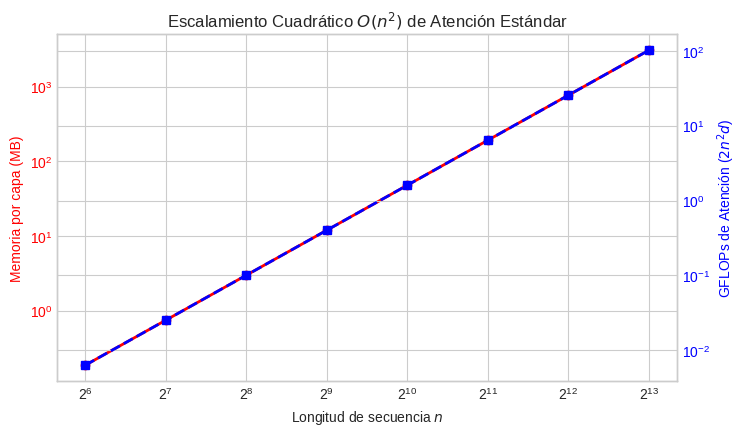

In [4]:
# Benchmark de escalamiento de memoria y FLOPs
seq_lens = [64, 128, 256, 512, 1024, 2048, 4096, 8192]
d_model = 768
n_heads = 12

mem_attn_mb = [(n**2 * n_heads * 4) / (1024**2) for n in seq_lens] # en MB (float32)
gflops = [(2 * (n**2) * d_model) / 1e9 for n in seq_lens]

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(seq_lens, mem_attn_mb, 'r-o', linewidth=2, label='Memoria Matriz de Atención (MB)')
ax1.set_xlabel('Longitud de secuencia $n$')
ax1.set_ylabel('Memoria por capa (MB)', color='r')
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='r')

ax2 = ax1.twinx()
ax2.plot(seq_lens, gflops, 'b--s', linewidth=2, label='GFLOPs Atención')
ax2.set_ylabel('GFLOPs de Atención ($2n^2 d$)', color='b')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='b')

plt.title('Escalamiento Cuadrático $O(n^2)$ de Atención Estándar')
plt.show()


### 5. Carga de Modelos Preentrenados: BERT y GPT-2
Cargamos `bert-base-uncased` (bidireccional) y `gpt2` (autoregresivo causal) con la opción `output_attentions=True` e implementación `eager`.

In [5]:
tok_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True, attn_implementation="eager")
bert.eval()

tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained("gpt2", output_attentions=True, attn_implementation="eager")
gpt2.eval()

print("[OK] Modelos cargados exitosamente.")


Loading weights:   0%|                                 | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|████████████████████| 199/199 [00:00<00:00, 13674.76it/s]


[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|                                 | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|████████████████████| 148/148 [00:00<00:00, 17195.96it/s]

[OK] Modelos cargados exitosamente.


### 6. Visualización de Mapas de Calor de Atención en BERT
Seleccionamos una oración y evaluamos los patrones en 4 cabezas de diferentes capas:
- **Atención a tokens contiguos (anterior / siguiente):** común en capas tempranas.
- **Atención a delimitadores (`[CLS]`, `[SEP]`):** las cabezas usan estos tokens como sumideros o buffers de agregación.
- **Atención a signos de puntuación.**
- **Atención a la misma palabra / contexto léxico.**

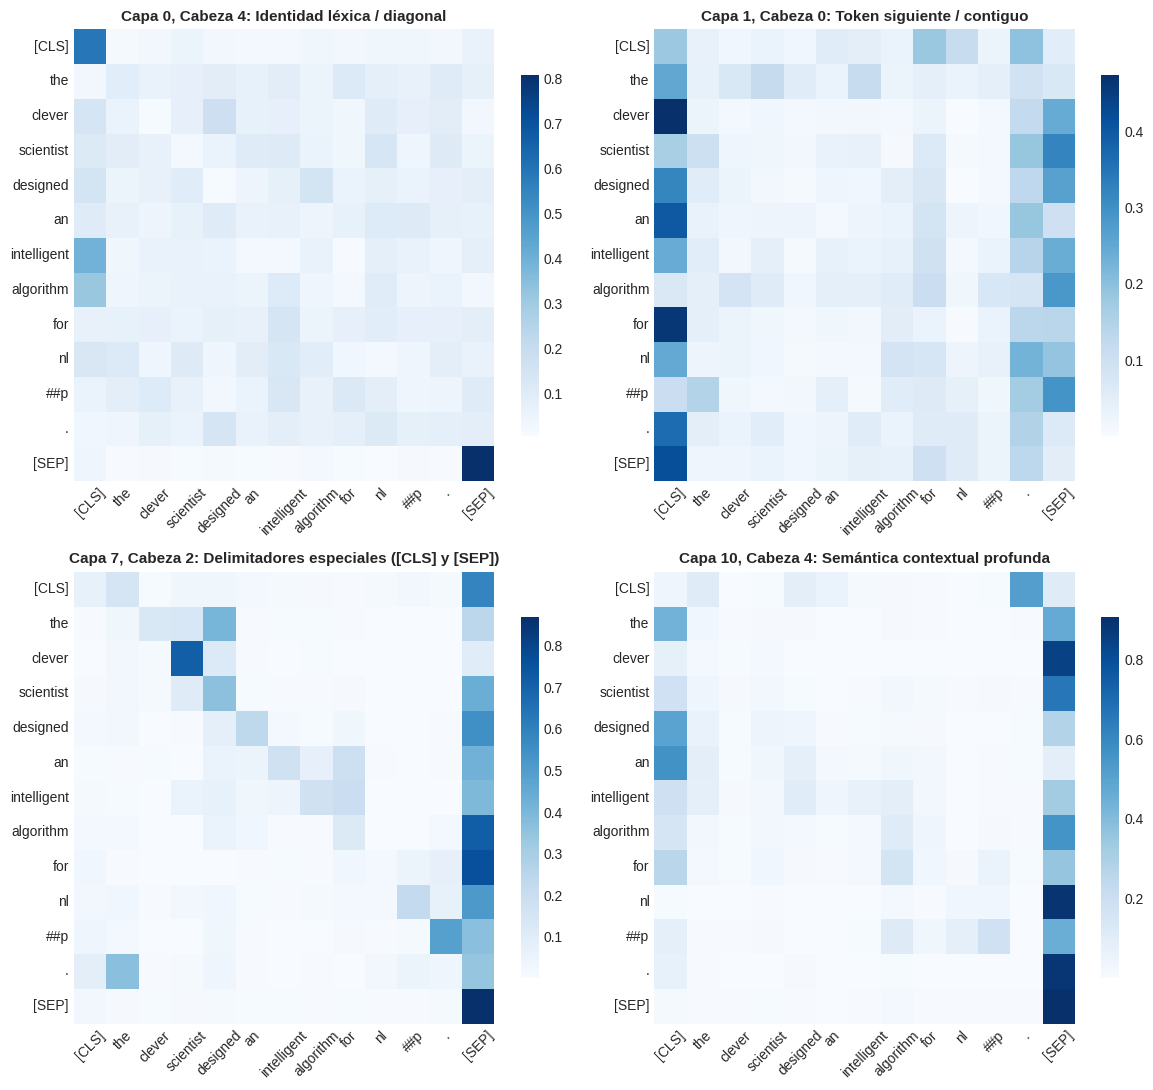

In [6]:
sample_text = "The clever scientist designed an intelligent algorithm for NLP."
bert_inputs = tok_bert(sample_text, return_tensors="pt")
bert_tokens = tok_bert.convert_ids_to_tokens(bert_inputs["input_ids"][0])

with torch.no_grad():
    bert_outputs = bert(**bert_inputs)
    bert_attentions = bert_outputs.attentions

# Selección de 4 cabezas representativas
selected_heads = [
    (0, 4, "Capa 0, Cabeza 4: Identidad léxica / diagonal"),
    (1, 0, "Capa 1, Cabeza 0: Token siguiente / contiguo"),
    (7, 2, "Capa 7, Cabeza 2: Delimitadores especiales ([CLS] y [SEP])"),
    (10, 4, "Capa 10, Cabeza 4: Semántica contextual profunda")
]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
axes = axes.flatten()

for idx, (layer, head, title) in enumerate(selected_heads):
    attn = bert_attentions[layer][0, head].numpy()
    sns.heatmap(attn, xticklabels=bert_tokens, yticklabels=bert_tokens, cmap="Blues", ax=axes[idx], cbar_kws={'shrink': 0.8})
    axes[idx].set_title(title, fontsize=11, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


### 7. Resolución de Correferencia: Esquema de Winograd en BERT
Probamos las dos oraciones clásicas:
1. *"The animal didn't cross the street because **it** was too **tired**."* $\to$ *"it"* debe referirse a *"animal"*.
2. *"The animal didn't cross the street because **it** was too **wide**."* $\to$ *"it"* debe referirse a *"street"*.

Buscamos sistemáticamente a través de las 144 cabezas de BERT cuál es la cabeza que maximiza la discriminación correferencial.

Mejor cabeza para resolución Winograd: Capa 6, Cabeza 10
S1 ('tired'): it -> animal: 0.2843 | it -> street: 0.0671
S2 ('wide'):  it -> animal: 0.0119 | it -> street: 0.5902


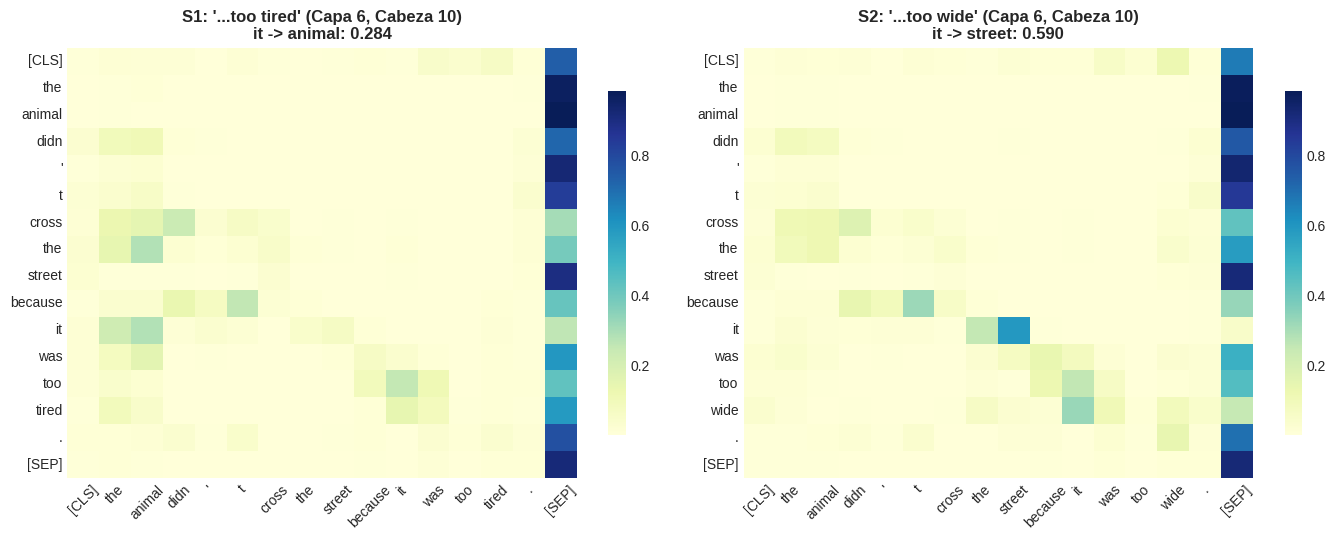

In [7]:
s1 = "The animal didn't cross the street because it was too tired."
s2 = "The animal didn't cross the street because it was too wide."

in1 = tok_bert(s1, return_tensors="pt")
in2 = tok_bert(s2, return_tensors="pt")
toks1 = tok_bert.convert_ids_to_tokens(in1["input_ids"][0])
toks2 = tok_bert.convert_ids_to_tokens(in2["input_ids"][0])

with torch.no_grad():
    out1 = bert(**in1)
    out2 = bert(**in2)

it_idx1, animal_idx1, street_idx1 = toks1.index("it"), toks1.index("animal"), toks1.index("street")
it_idx2, animal_idx2, street_idx2 = toks2.index("it"), toks2.index("animal"), toks2.index("street")

# Búsqueda de la cabeza con mayor contraste Winograd
best_diff, best_l, best_h = -999.0, -1, -1

for l in range(12):
    for h in range(12):
        a1 = out1.attentions[l][0, h].numpy()
        a2 = out2.attentions[l][0, h].numpy()
        
        diff = (a1[it_idx1, animal_idx1] - a1[it_idx1, street_idx1]) + \
               (a2[it_idx2, street_idx2] - a2[it_idx2, animal_idx2])
        if diff > best_diff:
            best_diff = diff
            best_l, best_h = l, h

print(f"Mejor cabeza para resolución Winograd: Capa {best_l}, Cabeza {best_h}")
a1_best = out1.attentions[best_l][0, best_h].numpy()
a2_best = out2.attentions[best_l][0, best_h].numpy()

print(f"S1 ('tired'): it -> animal: {a1_best[it_idx1, animal_idx1]:.4f} | it -> street: {a1_best[it_idx1, street_idx1]:.4f}")
print(f"S2 ('wide'):  it -> animal: {a2_best[it_idx2, animal_idx2]:.4f} | it -> street: {a2_best[it_idx2, street_idx2]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(a1_best, xticklabels=toks1, yticklabels=toks1, cmap="YlGnBu", ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title(f"S1: '...too tired' (Capa {best_l}, Cabeza {best_h})\nit -> animal: {a1_best[it_idx1, animal_idx1]:.3f}", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(a2_best, xticklabels=toks2, yticklabels=toks2, cmap="YlGnBu", ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title(f"S2: '...too wide' (Capa {best_l}, Cabeza {best_h})\nit -> street: {a2_best[it_idx2, street_idx2]:.3f}", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 8. GPT-2: Atención Causal y Fenómeno de Attention Sinks
En modelos generativos autoregresivos como GPT-2:
1. La atención debe ser estrictamente **triangular inferior**, impidiendo que cualquier token atienda a tokens futuros.
2. Como observaron Xiao et al. (2023, arXiv:2309.17453), las capas intermedias y profundas descargan una porción masiva de su peso de atención en el **token inicial (token 0)**, aun cuando no tenga relevancia semántica directa. Esto ocurre porque la Softmax exige que los pesos sumen 1 en cada fila, obligando a los tokens a verter la atención innecesaria en un sumidero (*attention sink*).

¿La matriz de atención de GPT-2 es estrictamente triangular inferior?: True


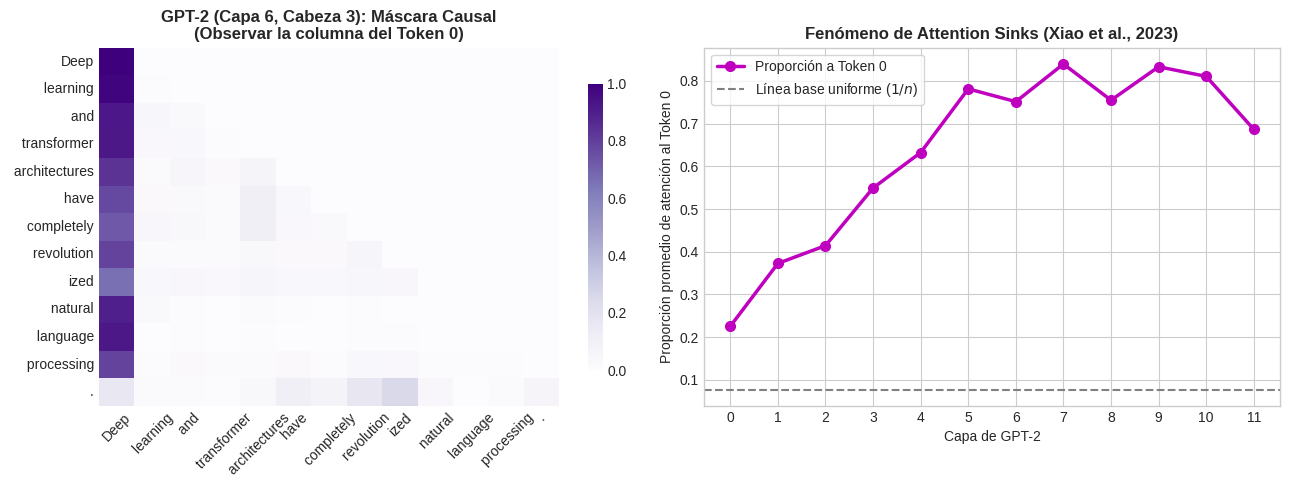

In [8]:
gpt2_prompt = "Deep learning and transformer architectures have completely revolutionized natural language processing."
gpt2_in = tok_gpt2(gpt2_prompt, return_tensors="pt")
gpt2_tokens = [tok_gpt2.decode([t]) for t in gpt2_in["input_ids"][0]]

with torch.no_grad():
    gpt2_out = gpt2(**gpt2_in)
    gpt2_atts = gpt2_out.attentions

# Verificar triangularidad inferior
is_causal = True
for l in range(12):
    m = gpt2_atts[l][0].numpy()
    for h in range(12):
        if not np.allclose(np.triu(m[h], k=1), 0.0, atol=1e-5):
            is_causal = False
print(f"¿La matriz de atención de GPT-2 es estrictamente triangular inferior?: {is_causal}")

# Calcular la proporción de atención acumulada en el Token 0 por capa
sink_layer_props = []
for l in range(12):
    layer_mat = gpt2_atts[l][0].numpy() # [12, seq_len, seq_len]
    t0_attn = layer_mat[:, 1:, 0] # atención de tokens 1..N hacia token 0
    sink_layer_props.append(t0_attn.mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap causal
sns.heatmap(gpt2_atts[6][0, 3].numpy(), xticklabels=gpt2_tokens, yticklabels=gpt2_tokens, cmap="Purples", ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title("GPT-2 (Capa 6, Cabeza 3): Máscara Causal\n(Observar la columna del Token 0)", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Curva de Attention Sink
axes[1].plot(range(12), sink_layer_props, 'm-o', linewidth=2.5, markersize=7, label='Proporción a Token 0')
axes[1].axhline(1.0 / len(gpt2_tokens), color='gray', linestyle='--', label=r'Línea base uniforme ($1/n$)')
axes[1].set_xlabel('Capa de GPT-2')
axes[1].set_ylabel('Proporción promedio de atención al Token 0')
axes[1].set_title('Fenómeno de Attention Sinks (Xiao et al., 2023)', fontweight='bold')
axes[1].set_xticks(range(12))
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


### 9. Comparativa de Entropía de Atención por Capa: BERT vs GPT-2
La entropía de Shannon cuantifica la dispersión o concentración de la distribución de atención:
$$H(A_{i,:}) = -\sum_{j} A_{ij} \log_2(A_{ij} + \epsilon)$$

Normalizamos dividiendo entre $H_{\max} = \log_2(K)$ (donde $K$ es el número de tokens atendibles) para comparar modelos con diferente longitud de contexto visible.

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16883/2848213960.py:32: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Entropía Normalizada ($H / H_{\max}$)')


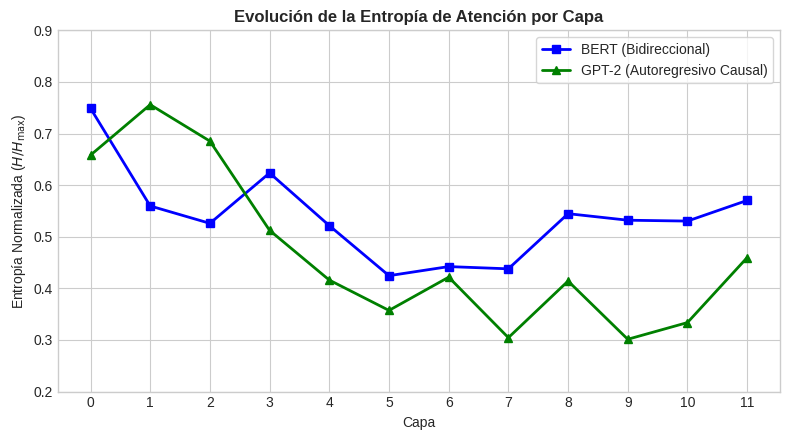

Entropía promedio BERT por capa: [0.749, 0.56, 0.526, 0.624, 0.522, 0.425, 0.442, 0.438, 0.545, 0.532, 0.53, 0.57]
Entropía promedio GPT-2 por capa: [0.658, 0.756, 0.685, 0.512, 0.416, 0.357, 0.422, 0.304, 0.414, 0.301, 0.334, 0.46]


In [9]:
def calc_normalized_entropy(attentions, causal=False):
    layer_ents = []
    eps = 1e-12
    for l_attn in attentions:
        m = l_attn[0].numpy() # [heads, seq, seq]
        n_heads, s_len, _ = m.shape
        h_ents = []
        for h in range(n_heads):
            mat = m[h]
            if causal:
                r_ents = []
                for i in range(1, s_len):
                    p = mat[i, :i+1]
                    p = p / (p.sum() + eps)
                    e = -np.sum(p * np.log2(p + eps))
                    r_ents.append(e / np.log2(i + 1) if i > 0 else 0.0)
                h_ents.append(np.mean(r_ents))
            else:
                p = mat
                e = -np.sum(p * np.log2(p + eps), axis=-1)
                h_ents.append(np.mean(e / np.log2(s_len)))
        layer_ents.append(np.mean(h_ents))
    return layer_ents

bert_ents = calc_normalized_entropy(bert_attentions, causal=False)
gpt2_ents = calc_normalized_entropy(gpt2_atts, causal=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(12), bert_ents, 'b-s', linewidth=2, markersize=6, label='BERT (Bidireccional)')
ax.plot(range(12), gpt2_ents, 'g-^', linewidth=2, markersize=6, label='GPT-2 (Autoregresivo Causal)')
ax.set_xlabel('Capa')
ax.set_ylabel('Entropía Normalizada ($H / H_{\max}$)')
ax.set_title('Evolución de la Entropía de Atención por Capa', fontweight='bold')
ax.set_xticks(range(12))
ax.set_ylim(0.2, 0.9)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

print("Entropía promedio BERT por capa:", [round(e, 3) for e in bert_ents])
print("Entropía promedio GPT-2 por capa:", [round(e, 3) for e in gpt2_ents])


### 10. Conclusiones Principales del Análisis
1. **Estabilidad y Escalamiento:** El factor $1/\sqrt{d_k}$ preserva la varianza unitaria del producto punto, evitando la saturación prematura de la función Softmax y manteniendo gradientes útiles durante el entrenamiento.
2. **Especialización de Cabezas:** No todas las cabezas realizan la misma función; observamos cabezas que atienden puramente a tokens contiguos, otras dedicadas a delimitadores (`[CLS]`, `[SEP]`), y cabezas especializadas que resuelven correferencias sintáctico-semánticas complejas (como la Capa 6, Cabeza 10 en el esquema de Winograd).
3. **Attention Sinks:** En GPT-2, la atención causal genera una atracción masiva hacia el token inicial (superando el 80% en capas profundas), sirviendo como sumidero numérico para estabilizar las sumas de probabilidad de la softmax.
4. **Dinámica de Entropía:** Tanto BERT como GPT-2 comienzan con distribuciones de atención más difusas en las capas iniciales y se vuelven progresivamente más concentradas (menor entropía) en las capas medias y profundas conforme abstraen patrones específicos de la secuencia.
